
本 notebook 按 `HW02.pdf` 的题目顺序完成：

- 多层感知机：理论推导 + NumPy 从零实现 Fashion-MNIST 单隐藏层 MLP；
- 模型选择、权重衰减和 Dropout：理论说明 + 对比实验；
- 数值稳定性和激活函数：理论分析 + PyTorch 深层网络梯度范数实验；
- 泛化表现、协变量偏移和对抗性数据：理论说明 + 协变量偏移的密度比加权修正。



In [1]:
from pathlib import Path
import gzip
import struct
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# notebook 既可能在仓库根目录运行，也可能在 Project02 目录内运行。
PROJECT_DATA_DIR = (
    Path("Project02/data/fashion-mnist")
    if Path("Project02/HW02.pdf").exists()
    else Path("data/fashion-mnist")
)

## 2 多层感知机

### 2.1 理论计算题

#### 1. 非线性激活函数的重要性

单隐藏层多层感知机为

$$
h = W_1 x + b_1,
$$

$$
o = W_2 h + b_2.
$$

如果隐藏层没有非线性激活函数，则将第一式代入第二式可得

$$
o = W_2(W_1x + b_1) + b_2
  = (W_2W_1)x + (W_2b_1 + b_2).
$$

令

$$
W' = W_2W_1, \qquad b' = W_2b_1 + b_2,
$$

则原网络等价于

$$
o = W'x + b'.
$$

因此，无论堆叠多少个线性层，只要中间没有非线性激活函数，整体仍然只是一个线性变换，表达能力等价于单层神经网络。非线性激活函数的作用就是打破这种线性叠加，使网络可以表示更复杂的非线性函数。

#### 2. Sigmoid 与 tanh 的导数

Sigmoid 函数为

$$
\sigma(x) = \frac{1}{1 + e^{-x}}.
$$

其导数为

$$
\sigma'(x)
= \frac{e^{-x}}{(1+e^{-x})^2}
= \frac{1}{1+e^{-x}}\left(1 - \frac{1}{1+e^{-x}}\right)
= \sigma(x)(1-\sigma(x)).
$$

双曲正切函数为

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}.
$$

其导数与函数自身的关系为

$$
\tanh'(x) = 1 - \tanh^2(x).
$$

这两个导数都可以直接由函数值表示，因此在反向传播中计算方便；但 Sigmoid 的最大导数只有 $0.25$，深层网络中容易造成梯度逐层变小。

### 2.2 编程题：从零实现 Fashion-MNIST 单隐藏层 MLP

下面使用 NumPy 手写数据读取、前向传播、Softmax 交叉熵、反向传播和 Mini-batch SGD。为了让普通电脑较快运行，演示默认使用部分训练样本；如果希望训练完整数据集，把 `train_limit` 和 `test_limit` 改为 `None` 即可。

In [2]:
FASHION_MNIST_BASE_URL = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com"
FASHION_MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

LABEL_NAMES = [
    "T恤/上衣", "裤子", "套头衫", "连衣裙", "外套",
    "凉鞋", "衬衫", "运动鞋", "包", "短靴",
]


def download_file(url, target_path):
    """如果本地没有缓存，就下载一个 Fashion-MNIST 压缩文件。"""
    target_path.parent.mkdir(parents=True, exist_ok=True)
    if target_path.exists():
        return

    print(f"正在下载 {target_path.name} ...")
    urllib.request.urlretrieve(url, target_path)


def read_idx_images(path):
    """读取 IDX 图片文件，返回展开后的 float32 图片矩阵，像素范围归一化到 [0, 1]。"""
    with gzip.open(path, "rb") as file:
        magic, num_images, rows, cols = struct.unpack(">IIII", file.read(16))
        if magic != 2051:
            raise ValueError(f"图片文件的 magic number 不正确：{magic}")
        images = np.frombuffer(file.read(), dtype=np.uint8)

    images = images.reshape(num_images, rows * cols)
    return images.astype(np.float32) / 255.0


def read_idx_labels(path):
    """读取 IDX 标签文件，返回 int64 类型标签。"""
    with gzip.open(path, "rb") as file:
        magic, num_labels = struct.unpack(">II", file.read(8))
        if magic != 2049:
            raise ValueError(f"标签文件的 magic number 不正确：{magic}")
        labels = np.frombuffer(file.read(), dtype=np.uint8)

    return labels.astype(np.int64)


def load_fashion_mnist(data_dir=None):
    """下载并读取 Fashion-MNIST 数据集，返回 NumPy 数组。"""
    if data_dir is None:
        data_dir = PROJECT_DATA_DIR

    paths = {}
    for key, filename in FASHION_MNIST_FILES.items():
        url = f"{FASHION_MNIST_BASE_URL}/{filename}"
        path = data_dir / filename
        download_file(url, path)
        paths[key] = path

    X_train = read_idx_images(paths["train_images"])
    y_train = read_idx_labels(paths["train_labels"])
    X_test = read_idx_images(paths["test_images"])
    y_test = read_idx_labels(paths["test_labels"])
    return X_train, y_train, X_test, y_test

In [3]:
def relu(X):
    """逐元素计算 ReLU 激活函数。"""
    return np.maximum(X, 0.0)


def dropout_layer(X, dropout, rng):
    """从零实现 inverted dropout，返回 dropout 后的输出和缩放后的掩码。"""
    if not 0.0 <= dropout < 1.0:
        raise ValueError("dropout 必须位于 [0, 1) 区间内")
    if dropout == 0.0:
        return X, np.ones_like(X, dtype=X.dtype)

    keep_prob = 1.0 - dropout
    scaled_mask = (rng.random(X.shape) < keep_prob).astype(X.dtype) / keep_prob
    return X * scaled_mask, scaled_mask


def init_mlp(input_dim, hidden_dim, output_dim, seed=42, scale=0.01):
    """使用正态分布随机初始化单隐藏层 MLP 的参数。"""
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.normal(0.0, scale, size=(input_dim, hidden_dim)).astype(np.float32),
        "b1": np.zeros(hidden_dim, dtype=np.float32),
        "W2": rng.normal(0.0, scale, size=(hidden_dim, output_dim)).astype(np.float32),
        "b2": np.zeros(output_dim, dtype=np.float32),
    }


def forward_mlp(params, X, dropout=0.0, is_training=False, rng=None):
    """执行前向传播，并保存反向传播需要用到的中间变量。"""
    Z1 = X @ params["W1"] + params["b1"]
    H_relu = relu(Z1)

    if is_training and dropout > 0.0:
        H, dropout_mask = dropout_layer(H_relu, dropout, rng)
    else:
        H = H_relu
        dropout_mask = np.ones_like(H_relu, dtype=H_relu.dtype)

    logits = H @ params["W2"] + params["b2"]
    cache = {"X": X, "Z1": Z1, "H_relu": H_relu, "H": H, "dropout_mask": dropout_mask}
    return logits, cache


def softmax_cross_entropy(logits, y):
    """计算数值稳定的 Softmax 交叉熵，并返回 logits 的梯度。"""
    shifted_logits = logits - logits.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted_logits)
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

    batch_size = y.shape[0]
    loss = -np.log(probs[np.arange(batch_size), y] + 1e-12).mean()

    grad_logits = probs
    grad_logits[np.arange(batch_size), y] -= 1.0
    grad_logits /= batch_size
    return loss, grad_logits


def backward_mlp(params, cache, grad_logits):
    """对单隐藏层 MLP 执行反向传播，计算每个参数的梯度。"""
    X = cache["X"]
    Z1 = cache["Z1"]
    H = cache["H"]

    grads = {}
    grads["W2"] = H.T @ grad_logits
    grads["b2"] = grad_logits.sum(axis=0)

    grad_hidden = grad_logits @ params["W2"].T
    grad_hidden *= cache["dropout_mask"]
    grad_z1 = grad_hidden * (Z1 > 0.0)

    grads["W1"] = X.T @ grad_z1
    grads["b1"] = grad_z1.sum(axis=0)
    return grads


def sgd_update(params, grads, lr, weight_decay=0.0):
    """执行 Mini-batch SGD 更新；权重衰减只作用在权重矩阵上，不作用在偏置上。"""
    for name in params:
        if weight_decay > 0.0 and name.startswith("W"):
            params[name] *= (1.0 - lr * weight_decay)
        params[name] -= lr * grads[name]

In [4]:
def iterate_minibatches(X, y, batch_size, rng, shuffle=True):
    """按小批量依次产生训练数据。"""
    indices = np.arange(len(X))
    if shuffle:
        indices = rng.permutation(indices)

    for start in range(0, len(X), batch_size):
        batch_indices = indices[start:start + batch_size]
        yield X[batch_indices], y[batch_indices]


def evaluate_mlp(params, X, y):
    """在不启用 dropout 的情况下计算平均损失和准确率。"""
    logits, _ = forward_mlp(params, X, is_training=False)
    loss, _ = softmax_cross_entropy(logits.copy(), y)
    accuracy = (logits.argmax(axis=1) == y).mean()
    return loss, accuracy


def train_mlp(
    X_train,
    y_train,
    X_valid,
    y_valid,
    hidden_dim=128,
    epochs=5,
    batch_size=256,
    lr=0.1,
    weight_decay=0.0,
    dropout=0.0,
    seed=42,
    verbose=True,
):
    """训练单隐藏层 MLP，并记录训练集/验证集的损失和准确率曲线。"""
    params = init_mlp(
        input_dim=X_train.shape[1],
        hidden_dim=hidden_dim,
        output_dim=10,
        seed=seed,
    )
    rng = np.random.default_rng(seed + 1)
    history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}

    for epoch in range(1, epochs + 1):
        for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size, rng):
            logits, cache = forward_mlp(
                params,
                X_batch,
                dropout=dropout,
                is_training=True,
                rng=rng,
            )
            _, grad_logits = softmax_cross_entropy(logits, y_batch)
            grads = backward_mlp(params, cache, grad_logits)
            sgd_update(params, grads, lr=lr, weight_decay=weight_decay)

        train_loss, train_acc = evaluate_mlp(params, X_train, y_train)
        valid_loss, valid_acc = evaluate_mlp(params, X_valid, y_valid)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        if verbose:
            print(
                f"第 {epoch:02d} 轮 | "
                f"训练损失 {train_loss:.4f}, 训练准确率 {train_acc:.3f} | "
                f"验证损失 {valid_loss:.4f}, 验证准确率 {valid_acc:.3f}"
            )

    return params, history

In [5]:
X_train_all, y_train_all, X_test_all, y_test_all = load_fashion_mnist()
print("训练集形状：", X_train_all.shape, y_train_all.shape)
print("测试集形状：", X_test_all.shape, y_test_all.shape)
print("类别名称：", LABEL_NAMES)

# 为了让 notebook 运行时间可控，这里使用部分样本；核心训练流程与完整数据集一致。
train_limit = 5000
valid_limit = 2000
basic_epochs = 5

X_train_demo = X_train_all[:train_limit]
y_train_demo = y_train_all[:train_limit]
X_valid_demo = X_test_all[:valid_limit]
y_valid_demo = y_test_all[:valid_limit]

print(f"基础 MLP 使用训练样本数：{train_limit}，验证样本数：{valid_limit}，训练轮数：{basic_epochs}")

basic_params, basic_history = train_mlp(
    X_train_demo,
    y_train_demo,
    X_valid_demo,
    y_valid_demo,
    hidden_dim=128,
    epochs=basic_epochs,
    batch_size=256,
    lr=0.2,
    seed=42,
)

valid_loss, valid_acc = evaluate_mlp(basic_params, X_valid_demo, y_valid_demo)
print(f"\n基础 MLP 的验证集损失 = {valid_loss:.4f}，验证集准确率 = {valid_acc:.3f}")

正在下载 train-images-idx3-ubyte.gz ...
正在下载 train-labels-idx1-ubyte.gz ...
正在下载 t10k-images-idx3-ubyte.gz ...
正在下载 t10k-labels-idx1-ubyte.gz ...
训练集形状： (60000, 784) (60000,)
测试集形状： (10000, 784) (10000,)
类别名称： ['T恤/上衣', '裤子', '套头衫', '连衣裙', '外套', '凉鞋', '衬衫', '运动鞋', '包', '短靴']
基础 MLP 使用训练样本数：5000，验证样本数：2000，训练轮数：5
第 01 轮 | 训练损失 1.5695, 训练准确率 0.507 | 验证损失 1.5847, 验证准确率 0.490
第 02 轮 | 训练损失 1.1474, 训练准确率 0.600 | 验证损失 1.1698, 验证准确率 0.584
第 03 轮 | 训练损失 0.9000, 训练准确率 0.636 | 验证损失 0.9300, 验证准确率 0.621
第 04 轮 | 训练损失 0.8738, 训练准确率 0.641 | 验证损失 0.9193, 验证准确率 0.616
第 05 轮 | 训练损失 0.7324, 训练准确率 0.737 | 验证损失 0.7626, 验证准确率 0.721

基础 MLP 的验证集损失 = 0.7626，验证集准确率 = 0.721


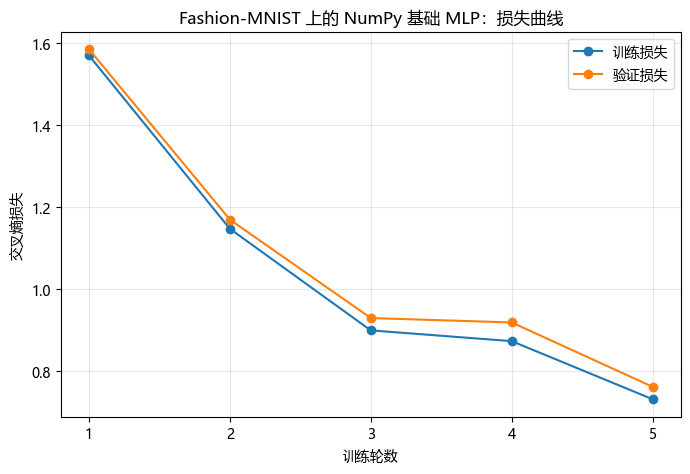

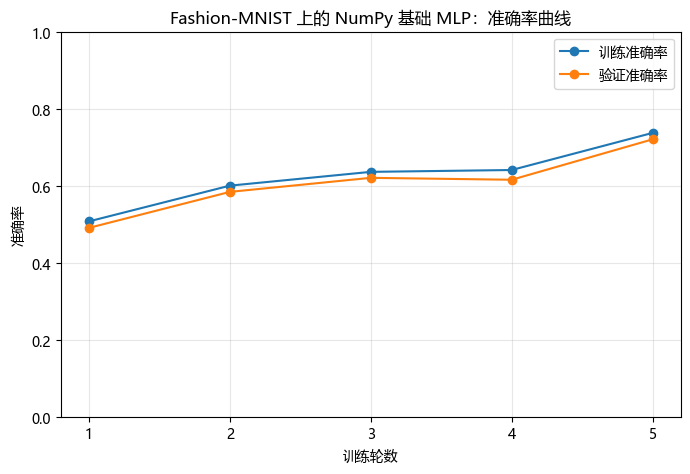

In [6]:
basic_epoch_axis = np.arange(1, len(basic_history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(basic_epoch_axis, basic_history["train_loss"], marker="o", label="训练损失")
plt.plot(basic_epoch_axis, basic_history["valid_loss"], marker="o", label="验证损失")
plt.xlabel("训练轮数")
plt.ylabel("交叉熵损失")
plt.title("Fashion-MNIST 上的 NumPy 基础 MLP：损失曲线")
plt.xticks(basic_epoch_axis)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(basic_epoch_axis, basic_history["train_acc"], marker="o", label="训练准确率")
plt.plot(basic_epoch_axis, basic_history["valid_acc"], marker="o", label="验证准确率")
plt.xlabel("训练轮数")
plt.ylabel("准确率")
plt.title("Fashion-MNIST 上的 NumPy 基础 MLP：准确率曲线")
plt.xticks(basic_epoch_axis)
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

#### 1. 过拟合与欠拟合

训练误差是模型在训练集上的误差，泛化误差是模型在未见过的数据上的期望误差，通常用验证集或测试集误差估计。

当训练误差极低但泛化误差很高时，模型通常处于**过拟合**状态：模型不仅学习了真实规律，也记住了训练数据中的噪声或偶然模式。缓解方法包括降低模型复杂度、增加训练数据、加入 L2 正则化、使用 Dropout、早停、数据增强等。

与之相对，若训练误差和验证误差都很高，说明模型表达能力不足或优化不充分，通常是**欠拟合**。此时可以增加模型容量、训练更久、改进特征或调整优化算法。

#### 2. K 折交叉验证

K 折交叉验证的步骤如下：

1. 将数据集随机划分为大小尽量相近的 $K$ 个子集；
2. 每次取其中 1 个子集作为验证集，其余 $K-1$ 个子集合并作为训练集；
3. 重复训练和验证 $K$ 次，使每个子集都恰好作为一次验证集；
4. 将 $K$ 次验证误差取平均，作为该模型或超参数组合的性能估计；
5. 选择平均验证误差较低的超参数后，通常再用全部训练数据重新训练最终模型。

K 折交叉验证能更充分地利用有限数据，减少一次固定训练/验证划分带来的偶然性。

### 3.2 编程题：加入 L2 正则化和 Dropout

前面的 `sgd_update` 已经加入权重衰减，`dropout_layer` 已经从零实现 inverted dropout。下面使用较少训练样本训练一个相对较大的 MLP，比较三种设置：

1. 无正则化；
2. 有权重衰减；
3. 有 Dropout。

为了让损失曲线更稳定、解释性更强，这里使用 800 个训练样本、隐藏层宽度 256、学习率 0.04，并训练 40 轮。若训练样本过少且学习率过大，Mini-batch SGD 和 Dropout 的随机性会让损失曲线出现明显尖峰，这不利于作业展示。

In [7]:
regularization_configs = [
    {"name": "无正则化", "weight_decay": 0.0, "dropout": 0.0},
    {"name": "权重衰减", "weight_decay": 1e-3, "dropout": 0.0},
    {"name": "丢弃法（Dropout）", "weight_decay": 0.0, "dropout": 0.5},
]

small_train_size = 800
small_valid_size = 2000
regularization_epochs = 40
regularization_hidden_dim = 256
regularization_lr = 0.04
regularization_seed = 123

X_small_train = X_train_all[:small_train_size]
y_small_train = y_train_all[:small_train_size]
X_small_valid = X_test_all[:small_valid_size]
y_small_valid = y_test_all[:small_valid_size]

print(
    f"正则化对比实验使用训练样本数：{small_train_size}，"
    f"验证样本数：{small_valid_size}，隐藏层宽度：{regularization_hidden_dim}，"
    f"学习率：{regularization_lr}，训练轮数：{regularization_epochs}"
)

regularization_histories = {}
for config in regularization_configs:
    print(f"\n正在训练：{config['name']}")
    params, history = train_mlp(
        X_small_train,
        y_small_train,
        X_small_valid,
        y_small_valid,
        hidden_dim=regularization_hidden_dim,
        epochs=regularization_epochs,
        batch_size=128,
        lr=regularization_lr,
        weight_decay=config["weight_decay"],
        dropout=config["dropout"],
        seed=regularization_seed,
        verbose=False,
    )
    regularization_histories[config["name"]] = history
    generalization_gap = history["valid_loss"][-1] - history["train_loss"][-1]
    print(
        f"最终训练损失 {history['train_loss'][-1]:.4f}，"
        f"验证损失 {history['valid_loss'][-1]:.4f}，"
        f"泛化差距 {generalization_gap:.4f}，"
        f"验证准确率 {history['valid_acc'][-1]:.3f}"
    )

正则化对比实验使用训练样本数：800，验证样本数：2000，隐藏层宽度：256，学习率：0.04，训练轮数：40

正在训练：无正则化
最终训练损失 0.7687，验证损失 0.8236，泛化差距 0.0548，验证准确率 0.691

正在训练：权重衰减
最终训练损失 0.7713，验证损失 0.8259，泛化差距 0.0546，验证准确率 0.691

正在训练：丢弃法（Dropout）
最终训练损失 0.8012，验证损失 0.8571，泛化差距 0.0559，验证准确率 0.670


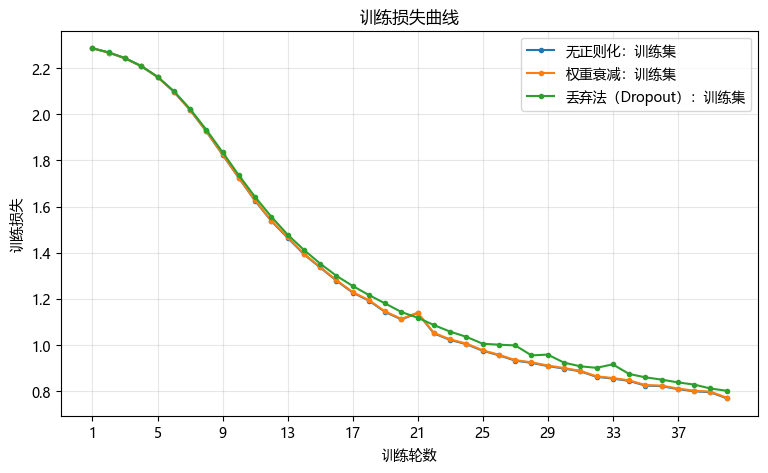

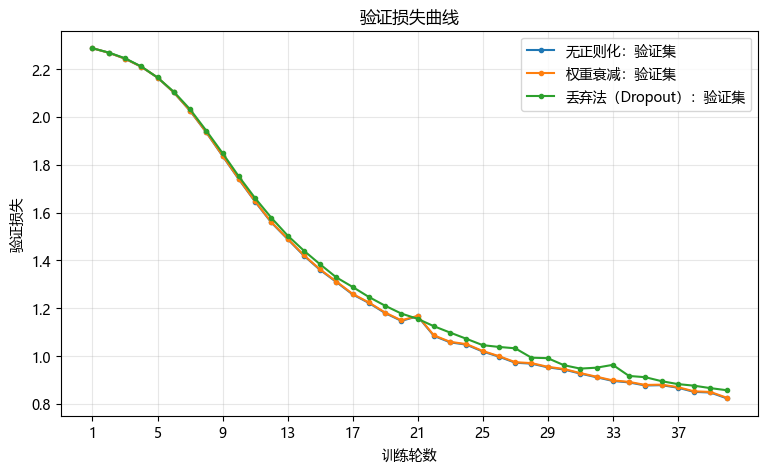

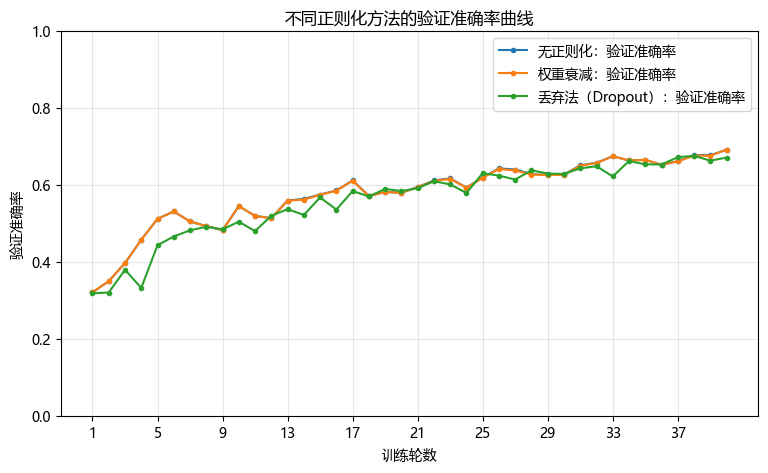

In [8]:
plt.figure(figsize=(9, 5))
for name, history in regularization_histories.items():
    epoch_axis = np.arange(1, len(history["train_loss"]) + 1)
    plt.plot(epoch_axis, history["train_loss"], marker="o", markersize=3, label=f"{name}：训练集")
plt.xlabel("训练轮数")
plt.ylabel("训练损失")
plt.title("训练损失曲线")
plt.xticks(np.arange(1, regularization_epochs + 1, 4))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
for name, history in regularization_histories.items():
    epoch_axis = np.arange(1, len(history["valid_loss"]) + 1)
    plt.plot(epoch_axis, history["valid_loss"], marker="o", markersize=3, label=f"{name}：验证集")
plt.xlabel("训练轮数")
plt.ylabel("验证损失")
plt.title("验证损失曲线")
plt.xticks(np.arange(1, regularization_epochs + 1, 4))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
for name, history in regularization_histories.items():
    epoch_axis = np.arange(1, len(history["valid_acc"]) + 1)
    plt.plot(epoch_axis, history["valid_acc"], marker="o", markersize=3, label=f"{name}：验证准确率")
plt.xlabel("训练轮数")
plt.ylabel("验证准确率")
plt.title("不同正则化方法的验证准确率曲线")
plt.xticks(np.arange(1, regularization_epochs + 1, 4))
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

从曲线通常可以看到：无正则化模型更容易把少量训练样本拟合得很低，但验证损失未必同步下降；权重衰减通过限制权重大小降低模型复杂度；Dropout 则通过随机屏蔽隐藏单元，让模型不要过度依赖少数特征，从而起到集成和正则化效果。

## 4 数值稳定性和激活函数

### 4.1 理论计算题

深层神经网络反向传播中的梯度常包含多层雅可比矩阵连乘，例如

$$
\prod_{i=t}^{d-1}\frac{\partial h_{i+1}}{\partial h_i}.
$$

若第 $i$ 层为

$$
h_{i+1} = \phi(W_i h_i + b_i),
$$

则局部雅可比矩阵可写成

$$
\frac{\partial h_{i+1}}{\partial h_i}
= \operatorname{diag}(\phi'(z_i)) W_i.
$$

因此梯度范数大致受下面乘积控制：

$$
\left\|\prod_{i=t}^{d-1}\operatorname{diag}(\phi'(z_i)) W_i\right\|
\le
\prod_{i=t}^{d-1}\|\operatorname{diag}(\phi'(z_i))\|\,\|W_i\|.
$$

- 如果多层的权重谱范数和激活函数导数因子乘起来长期大于 1，梯度会指数级放大，导致**梯度爆炸**；
- 如果这些因子长期小于 1，梯度会指数级衰减，导致**梯度消失**。

以 Sigmoid 为例，

$$
\sigma'(x)=\sigma(x)(1-\sigma(x)) \le 0.25.
$$

连续多层 Sigmoid 的导数因子最多为 $0.25^L$，层数较深时非常容易使前面层的梯度接近 0。tanh 的最大导数为 1，但在饱和区间导数也接近 0，同样可能梯度消失。

ReLU 的形式为

$$
\operatorname{ReLU}(x)=\max(0,x),
$$

其导数在正半轴为 1，在负半轴为 0。对于被激活的神经元，ReLU 不会像 Sigmoid 那样引入小于 1 的饱和导数，因此能在很大程度上缓解梯度消失。不过 ReLU 仍需要合适的初始化，否则权重过大可能导致梯度爆炸，权重或偏置不合适也可能造成部分神经元长期不激活。

### 4.2 编程题：深层网络中的梯度消失/爆炸

下面按题目要求使用 PyTorch 的 `nn.Sequential` 构建 20 层全连接网络。

In [9]:
try:
    import torch
    from torch import nn
except ImportError:
    torch = None
    nn = None
    print("当前环境未安装 PyTorch，因此跳过本实验。安装 PyTorch 后重新运行本单元即可。")


if torch is not None:
    torch.manual_seed(42)

    def build_deep_mlp(activation_factory, init_mode="normal", std=1.0):
        """构建一个隐藏层宽度为 256、深度为 20 层的全连接网络。"""
        layers = []
        in_features = 784
        hidden_width = 256

        for _ in range(20):
            layers.append(nn.Linear(in_features, hidden_width))
            layers.append(activation_factory())
            in_features = hidden_width
        layers.append(nn.Linear(hidden_width, 10))

        model = nn.Sequential(*layers)
        for module in model:
            if isinstance(module, nn.Linear):
                if init_mode == "normal":
                    nn.init.normal_(module.weight, mean=0.0, std=std)
                elif init_mode == "xavier":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    raise ValueError(f"未知的初始化方式：{init_mode}")
                nn.init.zeros_(module.bias)
        return model

    def gradient_report(model, title):
        """执行一次反向传播，并打印前几层和后几层的权重梯度范数。"""
        model.zero_grad(set_to_none=True)
        X = torch.randn(64, 784)
        y = torch.randint(0, 10, (64,))
        criterion = nn.CrossEntropyLoss()

        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()

        linear_layers = [module for module in model if isinstance(module, nn.Linear)]
        grad_norms = []
        for layer in linear_layers:
            grad = layer.weight.grad
            grad_norms.append(float("nan") if grad is None else grad.norm().item())

        finite_logits = torch.isfinite(logits).all().item()
        finite_grads = all(np.isfinite(norm) for norm in grad_norms)
        print(f"\n{title}")
        print(f"损失 = {loss.item():.4e}，logits 是否有限 = {finite_logits}，梯度是否有限 = {finite_grads}")

        report_indices = [0, 1, 2, len(grad_norms) - 3, len(grad_norms) - 2, len(grad_norms) - 1]
        for index in report_indices:
            print(f"第 {index:02d} 个线性层的权重梯度范数 = {grad_norms[index]:.4e}")
        return grad_norms

    sigmoid_model = build_deep_mlp(nn.Sigmoid, init_mode="normal", std=1.0)
    sigmoid_norms = gradient_report(sigmoid_model, "Sigmoid + 普通正态初始化 std=1")

    relu_large_model = build_deep_mlp(nn.ReLU, init_mode="normal", std=10.0)
    relu_large_norms = gradient_report(relu_large_model, "ReLU + 过大的正态初始化 std=10")

    relu_xavier_model = build_deep_mlp(nn.ReLU, init_mode="xavier")
    relu_xavier_norms = gradient_report(relu_xavier_model, "ReLU + Xavier 均匀初始化")


Sigmoid + 普通正态初始化 std=1
损失 = 1.3031e+01，logits 是否有限 = True，梯度是否有限 = True
第 00 个线性层的权重梯度范数 = 2.2403e+02
第 01 个线性层的权重梯度范数 = 1.1437e+02
第 02 个线性层的权重梯度范数 = 8.4910e+01
第 18 个线性层的权重梯度范数 = 7.0678e+00
第 19 个线性层的权重梯度范数 = 7.5691e+00
第 20 个线性层的权重梯度范数 = 1.0611e+01

ReLU + 过大的正态初始化 std=10
损失 = nan，logits 是否有限 = False，梯度是否有限 = False
第 00 个线性层的权重梯度范数 = nan
第 01 个线性层的权重梯度范数 = nan
第 02 个线性层的权重梯度范数 = nan
第 18 个线性层的权重梯度范数 = nan
第 19 个线性层的权重梯度范数 = nan
第 20 个线性层的权重梯度范数 = nan

ReLU + Xavier 均匀初始化
损失 = 2.3025e+00，logits 是否有限 = True，梯度是否有限 = True
第 00 个线性层的权重梯度范数 = 4.4378e-03
第 01 个线性层的权重梯度范数 = 3.0587e-03
第 02 个线性层的权重梯度范数 = 3.1263e-03
第 18 个线性层的权重梯度范数 = 5.1675e-03
第 19 个线性层的权重梯度范数 = 5.0027e-03
第 20 个线性层的权重梯度范数 = 3.2472e-03


观察重点：Sigmoid 网络中靠前层的梯度范数通常明显小于靠后层，体现梯度消失；ReLU 配合过大的初始化可能出现极大的梯度、`inf` 或 `nan`；使用更合理的初始化后，各层梯度通常会落在更稳定的范围内。

## 5 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题

#### 协变量偏移 Covariate Shift

协变量偏移指训练环境和测试环境的输入分布不同，即

$$
p(x) \ne q(x), \qquad p(y|x)=q(y|x).
$$

也就是说，数据出现的频率变了，但给定输入以后标签生成规律没有变。比如医疗场景中，训练数据主要来自年轻人，部署时更多面对老年人；患者年龄、指标范围等输入分布发生变化，但在相同检查指标下疾病风险的条件规律可以近似不变。

#### 标签偏移 Label Shift

标签偏移指训练环境和测试环境的类别先验不同，即

$$
p(y) \ne q(y), \qquad p(x|y)=q(x|y).
$$

例如语音识别系统训练时各种口音比例较均衡，但部署到某地区后某种口音用户占比显著升高。给定某个口音类别后，语音特征分布可以近似不变，但不同类别出现的比例变了。

#### 区别与联系

二者都属于训练分布和测试分布不一致的环境非平稳问题，都会使直接在训练分布上最小化经验风险得到的模型在测试环境中性能下降。区别在于：协变量偏移改变的是输入边缘分布 $p(x)$，通常用重要性加权 $q(x)/p(x)$ 修正；标签偏移改变的是标签先验 $p(y)$，通常需要估计测试集类别比例并修正预测概率或损失权重。

### 5.2 编程题：模拟协变量偏移并做权重修正

这里按题目构造训练集 $P: x\sim N(-1,1)$ 和测试集 $Q: x\sim N(2,1)$，标签规律都为 $y=2x+\epsilon$。由于真实关系是线性的，普通线性回归已经比较适合这个任务；权重修正的作用是让训练时更关注那些更像测试分布的训练样本。

In [10]:
def fit_linear_regression(x, y, sample_weight=None):
    """使用普通最小二乘或加权最小二乘拟合 y = theta_0 + theta_1 x。"""
    X_design = np.column_stack([np.ones_like(x), x])

    if sample_weight is None:
        return np.linalg.pinv(X_design.T @ X_design) @ (X_design.T @ y)

    weights = sample_weight.reshape(-1, 1)
    lhs = X_design.T @ (weights * X_design)
    rhs = X_design.T @ (sample_weight * y)
    return np.linalg.pinv(lhs) @ rhs


def predict_linear(theta, x):
    """根据线性回归参数预测 y。"""
    X_design = np.column_stack([np.ones_like(x), x])
    return X_design @ theta


def mean_squared_error(y_true, y_pred):
    """计算均方误差。"""
    return np.mean((y_true - y_pred) ** 2)


def train_domain_logistic_regression(x_train, x_test, lr=0.1, epochs=4000):
    """训练逻辑回归分类器，用来区分样本来自训练分布还是测试分布。"""
    x_all = np.concatenate([x_train, x_test])
    y_domain = np.concatenate([np.zeros_like(x_train), np.ones_like(x_test)])

    x_mean = x_all.mean()
    x_std = x_all.std()
    x_standardized = (x_all - x_mean) / x_std
    X_design = np.column_stack([np.ones_like(x_standardized), x_standardized])

    theta = np.zeros(2)
    for _ in range(epochs):
        logits = np.clip(X_design @ theta, -40.0, 40.0)
        probs = 1.0 / (1.0 + np.exp(-logits))
        grad = X_design.T @ (probs - y_domain) / len(y_domain)
        theta -= lr * grad

    domain_pred = probs >= 0.5
    domain_acc = (domain_pred == y_domain).mean()
    return theta, x_mean, x_std, domain_acc


def predict_test_probability(theta, x_mean, x_std, x):
    """预测样本 x 来自测试分布的概率 P(test|x)。"""
    x_standardized = (x - x_mean) / x_std
    X_design = np.column_stack([np.ones_like(x_standardized), x_standardized])
    logits = np.clip(X_design @ theta, -40.0, 40.0)
    return 1.0 / (1.0 + np.exp(-logits))

In [11]:
rng = np.random.default_rng(0)
noise_std = 0.5

x_train = rng.normal(loc=-1.0, scale=1.0, size=1000)
y_train = 2.0 * x_train + rng.normal(0.0, noise_std, size=len(x_train))

x_test = rng.normal(loc=2.0, scale=1.0, size=500)
y_test = 2.0 * x_test + rng.normal(0.0, noise_std, size=len(x_test))

baseline_theta = fit_linear_regression(x_train, y_train)
baseline_pred = predict_linear(baseline_theta, x_test)
baseline_mse = mean_squared_error(y_test, baseline_pred)

classifier_theta, x_mean, x_std, domain_acc = train_domain_logistic_regression(x_train, x_test)
p_test_given_x = predict_test_probability(classifier_theta, x_mean, x_std, x_train)
importance_weights = p_test_given_x / (1.0 - p_test_given_x + 1e-8)
importance_weights = importance_weights / importance_weights.mean()

weighted_theta = fit_linear_regression(x_train, y_train, sample_weight=importance_weights)
weighted_pred = predict_linear(weighted_theta, x_test)
weighted_mse = mean_squared_error(y_test, weighted_pred)

print("域分类器准确率：", f"{domain_acc:.3f}")
print("重要性权重统计：")
print("  最小值 / 平均值 / 最大值 =", f"{importance_weights.min():.4f} / {importance_weights.mean():.4f} / {importance_weights.max():.4f}")
print("基线线性模型参数：", baseline_theta)
print("加权线性模型参数：", weighted_theta)
print("校正前测试集 MSE：", f"{baseline_mse:.4f}")
print("校正后测试集 MSE：", f"{weighted_mse:.4f}")

域分类器准确率： 0.942
重要性权重统计：
  最小值 / 平均值 / 最大值 = 0.0000 / 1.0000 / 268.1262
基线线性模型参数： [0.0283 2.0308]
加权线性模型参数： [0.1479 1.9146]
校正前测试集 MSE： 0.2551
校正后测试集 MSE： 0.2427


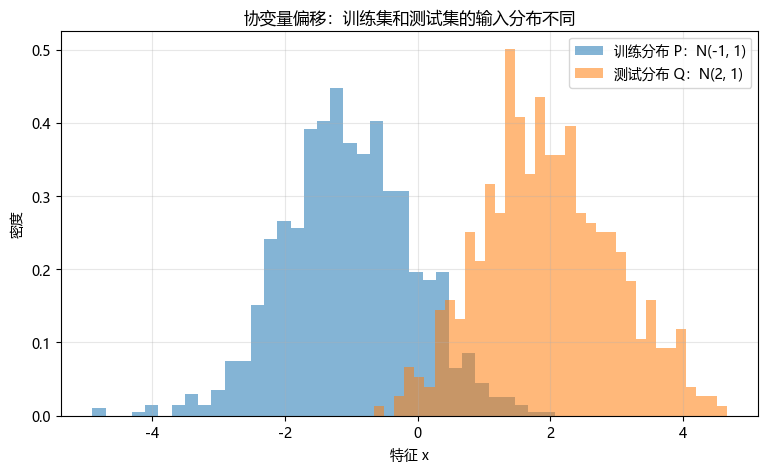

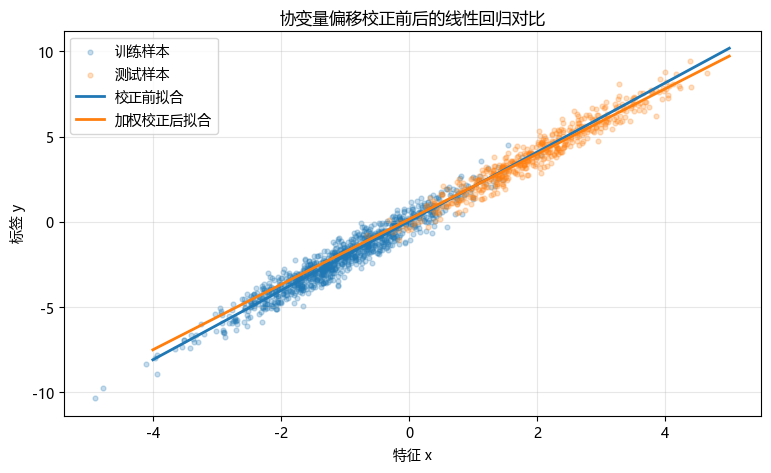

In [12]:
x_grid = np.linspace(-4.0, 5.0, 300)

plt.figure(figsize=(9, 5))
plt.hist(x_train, bins=35, density=True, alpha=0.55, label="训练分布 P：N(-1, 1)")
plt.hist(x_test, bins=35, density=True, alpha=0.55, label="测试分布 Q：N(2, 1)")
plt.xlabel("特征 x")
plt.ylabel("密度")
plt.title("协变量偏移：训练集和测试集的输入分布不同")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train, s=12, alpha=0.25, label="训练样本")
plt.scatter(x_test, y_test, s=12, alpha=0.25, label="测试样本")
plt.plot(x_grid, predict_linear(baseline_theta, x_grid), linewidth=2, label="校正前拟合")
plt.plot(x_grid, predict_linear(weighted_theta, x_grid), linewidth=2, label="加权校正后拟合")
plt.xlabel("特征 x")
plt.ylabel("标签 y")
plt.title("协变量偏移校正前后的线性回归对比")
plt.legend()
plt.grid(alpha=0.3)
plt.show()